# Facial Age Prediction — Preprocessing Pipeline (Google Colab)
### MTCNN + Dlib + OpenCV + CLAHE | Age range: 10–80

Dataset: [Kaggle mariafrenti/age-prediction](https://www.kaggle.com/datasets/mariafrenti/age-prediction)
Structure: `face_age/<age>/<image>.jpg` — one folder per exact age (1–100), ~160,000 images total,
~350–400 images per age (not perfectly uniform). No CSV — age comes from the folder name.
No provided bounding boxes or landmarks, so face detection is a required step.

**This notebook filters to ages 10–80** (drops the sparsest, most imbalanced tails) and runs:
`MTCNN (detect) → Dlib 68-landmark (precise eye alignment) → OpenCV (crop/resize) → CLAHE (lighting normalization)`

Runtime: Colab menu → Runtime → Change runtime type → **GPU (T4)**.


In [1]:
import numpy as np
import torch
import torchvision
import pandas as pd

print("numpy:", np.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("torchvision:", torchvision.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
torch: 2.10.0+cu128 | CUDA: True
torchvision: 0.25.0+cu128
pandas: 2.3.3


## 1. Setup — install packages

In [2]:
!pip install -q --no-deps facenet-pytorch
!pip install -q dlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
import torchvision
import pandas as pd

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("pandas:", pd.__version__)

from facenet_pytorch import MTCNN
print("facenet-pytorch imported OK")

import dlib
print("dlib imported OK")

numpy: 2.0.2
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
pandas: 2.3.3
facenet-pytorch imported OK
dlib imported OK


In [4]:
import os

DATA_ROOT = "/kaggle/input/datasets/mariafrenti/age-prediction/age_prediction_up/age_prediction"

print("Dataset exists:", os.path.isdir(DATA_ROOT))
print("Contents:", os.listdir(DATA_ROOT))
print("Sample train folders:", sorted(os.listdir(os.path.join(DATA_ROOT, "train")))[:5])

Dataset exists: True
Contents: ['test', 'train']
Sample train folders: ['001', '002', '003', '004', '005']


## 3. Download Dlib's 68-point facial landmark predictor

This is the standard pretrained shape predictor used for precise eye-based face alignment
(open, freely distributed model file from dlib.net).

In [5]:
# Download Dlib's 68-point facial landmark predictor (needed for eye-based alignment)
!wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 -O /kaggle/working/shape_predictor.dat.bz2
!bzip2 -d /kaggle/working/shape_predictor.dat.bz2
!ls -la /kaggle/working/shape_predictor.dat

-rw-r--r-- 1 root root 99693937 Jul 24  2015 /kaggle/working/shape_predictor.dat


**Note on Dlib install**: `pip install dlib` compiles from source and can take 5-10 minutes
on Colab. If it fails, an alternative is `!apt-get install -y cmake` first, then retry the pip install.

## 4. Build the labels table — filtered to ages 10–80

Age comes directly from the folder name. We filter to the 10–80 range here, which
also meaningfully reduces the class-imbalance problem versus the full 1–100 range.

In [6]:
import pandas as pd
import glob, os

MIN_AGE, MAX_AGE = 10, 80

records = []
for split in ["train", "test"]:
    split_path = os.path.join(DATA_ROOT, split)
    for age_folder in sorted(os.listdir(split_path)):
        folder_path = os.path.join(split_path, age_folder)
        if not os.path.isdir(folder_path):
            continue
        try:
            age = int(age_folder)  # handles zero-padded '001' -> 1 automatically
        except ValueError:
            continue
        if age < MIN_AGE or age > MAX_AGE:
            continue
        for img_path in glob.glob(os.path.join(folder_path, "*")):
            records.append({"filepath": img_path, "age": age, "original_split": split})

raw_df = pd.DataFrame(records)
print(f"Total images in age range [{MIN_AGE}, {MAX_AGE}]: {len(raw_df)}")
print(raw_df["age"].describe())
print(raw_df["original_split"].value_counts())
raw_df.head()

Total images in age range [10, 80]: 227985
count    227985.000000
mean         37.157528
std          13.304455
min          10.000000
25%          27.000000
50%          35.000000
75%          45.000000
max          80.000000
Name: age, dtype: float64
original_split
train    181773
test      46212
Name: count, dtype: int64


,filepath,age,original_split
0,/kaggle/input/datasets/mariafrenti/age-predict...,10,train
1,/kaggle/input/datasets/mariafrenti/age-predict...,10,train
2,/kaggle/input/datasets/mariafrenti/age-predict...,10,train
3,/kaggle/input/datasets/mariafrenti/age-predict...,10,train
4,/kaggle/input/datasets/mariafrenti/age-predict...,10,train


count      71.000000
mean     3211.056338
std      2542.850222
min       287.000000
25%       935.000000
50%      2201.000000
75%      5485.500000
max      8382.000000
Name: count, dtype: float64


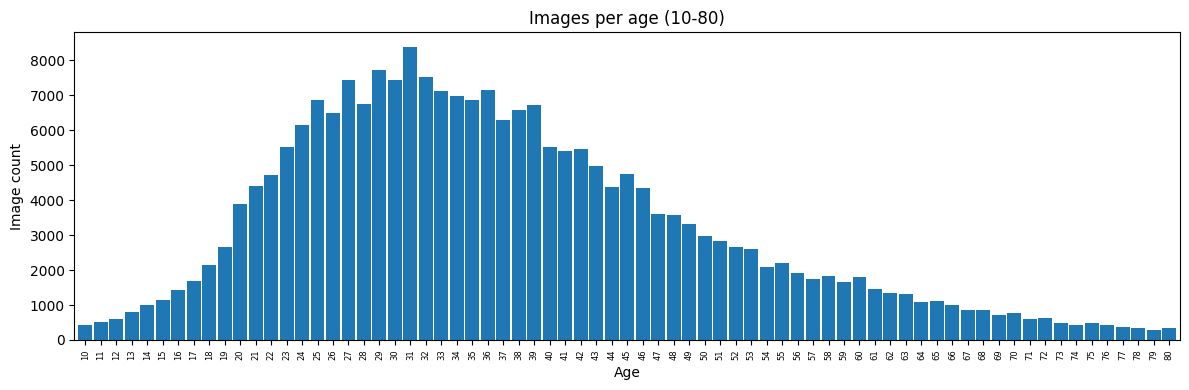

In [7]:
import matplotlib.pyplot as plt

age_counts = raw_df["age"].value_counts().sort_index()
print(age_counts.describe())

plt.figure(figsize=(12,4))
age_counts.plot(kind="bar", width=0.9)
plt.title("Images per age (10-80)")
plt.xlabel("Age")
plt.ylabel("Image count")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

In [8]:
CAP_PER_AGE = 600  # ages with fewer than this keep everything; richer ages get downsampled to this

subsampled_df = (
    raw_df.groupby("age", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), CAP_PER_AGE), random_state=42))
    .reset_index(drop=True)
)

print(f"Total images after capping at {CAP_PER_AGE}/age: {len(subsampled_df)}")
print(subsampled_df["age"].value_counts().sort_index().describe())

Total images after capping at 600/age: 40668
count     71.000000
mean     572.788732
std       72.173386
min      287.000000
25%      600.000000
50%      600.000000
75%      600.000000
max      600.000000
Name: count, dtype: float64


/tmp/ipykernel_23/2345192627.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP_PER_AGE), random_state=42))


## 5. Preprocessing pipeline

**Step-by-step per image:**
1. **MTCNN** — detects the face and returns a bounding box (fast, robust on in-the-wild photos)
2. **Dlib 68-landmark predictor** — run on the MTCNN box to get precise eye coordinates
3. **Rotation alignment** — rotate the image so the eye line is level (removes head-tilt variation)
4. **OpenCV crop + resize** — crop to the aligned face region, resize to 224×224
5. **CLAHE** — adaptive histogram equalization for consistent lighting/contrast across the dataset


In [9]:
import cv2
import dlib
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

mtcnn_detector = MTCNN(keep_all=False, select_largest=True, post_process=False, device=device)
dlib_predictor = dlib.shape_predictor("/kaggle/working/shape_predictor.dat")

LEFT_EYE_IDX = list(range(36, 42))
RIGHT_EYE_IDX = list(range(42, 48))


def get_eye_centers(landmarks):
    left_pts = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in LEFT_EYE_IDX])
    right_pts = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in RIGHT_EYE_IDX])
    return left_pts.mean(axis=0), right_pts.mean(axis=0)


def align_and_crop(image_bgr, box, target_size=224):
    x1, y1, x2, y2 = [int(v) for v in box]
    h, w = image_bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    dlib_rect = dlib.rectangle(x1, y1, x2, y2)
    landmarks = dlib_predictor(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), dlib_rect)
    left_eye, right_eye = get_eye_centers(landmarks)

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    eyes_center = ((left_eye[0] + right_eye[0]) / 2, (left_eye[1] + right_eye[1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)
    rotated = cv2.warpAffine(image_bgr, rot_mat, (w, h), flags=cv2.INTER_CUBIC)

    margin_x = int((x2 - x1) * 0.2)
    margin_y = int((y2 - y1) * 0.2)
    cx1, cy1 = max(0, x1 - margin_x), max(0, y1 - margin_y)
    cx2, cy2 = min(w, x2 + margin_x), min(h, y2 + margin_y)
    face_crop = rotated[cy1:cy2, cx1:cx2]

    if face_crop.size == 0:
        return None
    return cv2.resize(face_crop, (target_size, target_size), interpolation=cv2.INTER_AREA)


def apply_clahe(face_bgr):
    lab = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

print("Pipeline functions defined successfully.")

Using device: cuda
Pipeline functions defined successfully.


Success: 20/20


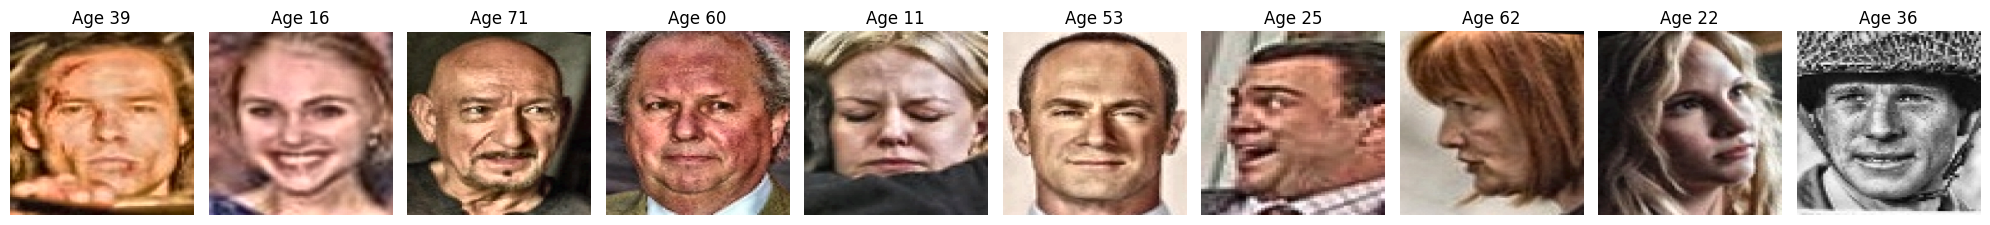

In [10]:
import matplotlib.pyplot as plt

test_batch = subsampled_df.sample(20, random_state=1).reset_index(drop=True)
results = []

for idx, row in test_batch.iterrows():
    pil_img = Image.open(row["filepath"]).convert("RGB")
    image_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    boxes, _ = mtcnn_detector.detect(pil_img)
    if boxes is None or len(boxes) == 0:
        results.append((None, "no_face_detected"))
        continue

    try:
        aligned = align_and_crop(image_bgr, boxes[0])
        if aligned is None:
            results.append((None, "empty_crop"))
            continue
        final = apply_clahe(aligned)
        results.append((final, "success"))
    except Exception as e:
        results.append((None, f"error: {e}"))

success_count = sum(1 for _, status in results if status == "success")
print(f"Success: {success_count}/20")
for _, status in results:
    if status != "success":
        print(status)

# visualize the successful ones
successes = [(img, test_batch.loc[i, "age"]) for i, (img, status) in enumerate(results) if status == "success"]
n = len(successes)
fig, axes = plt.subplots(1, min(n, 10), figsize=(20, 3))
for i, (img, age) in enumerate(successes[:10]):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Age {age}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 6. Run the full pipeline over the dataset

For each image: MTCNN detect → Dlib align → OpenCV crop/resize → CLAHE.
If MTCNN finds no face, or Dlib landmark detection fails on the box, the image is
logged to `skipped.csv` and excluded — expected for a small percentage of any
scraped, in-the-wild face dataset.

In [11]:
from tqdm import tqdm
import time

PROCESSED_DIR = "/kaggle/working/processed_faces_10_80"
os.makedirs(PROCESSED_DIR, exist_ok=True)

processed_records = []
skipped = []

start_time = time.time()

for idx, row in tqdm(subsampled_df.iterrows(), total=len(subsampled_df), desc="Preprocessing faces"):
    out_name = f"{idx}_{row['age']}.jpg"
    out_path = os.path.join(PROCESSED_DIR, out_name)

    # resumability: skip images already processed in a prior run
    if os.path.exists(out_path):
        processed_records.append({"filename": out_name, "age": row["age"]})
        continue

    try:
        pil_img = Image.open(row["filepath"]).convert("RGB")
    except Exception:
        skipped.append((row["filepath"], "unreadable_image"))
        continue

    image_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    boxes, _ = mtcnn_detector.detect(pil_img)
    if boxes is None or len(boxes) == 0:
        skipped.append((row["filepath"], "no_face_detected"))
        continue

    try:
        aligned = align_and_crop(image_bgr, boxes[0])
        if aligned is None:
            skipped.append((row["filepath"], "empty_crop"))
            continue
        final = apply_clahe(aligned)
    except Exception as e:
        skipped.append((row["filepath"], f"error: {e}"))
        continue

    cv2.imwrite(out_path, final)
    processed_records.append({"filename": out_name, "age": row["age"]})

    # periodic checkpoint save every 2000 images, in case of interruption
    if len(processed_records) % 2000 == 0:
        pd.DataFrame(processed_records).to_csv(os.path.join(PROCESSED_DIR, "processed_labels.csv"), index=False)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed/60:.1f} minutes")

processed_df = pd.DataFrame(processed_records)
processed_df.to_csv(os.path.join(PROCESSED_DIR, "processed_labels.csv"), index=False)

print(f"Processed: {len(processed_df)}  |  Skipped: {len(skipped)}")
if skipped:
    skip_df = pd.DataFrame(skipped, columns=["filepath", "reason"])
    skip_df.to_csv(os.path.join(PROCESSED_DIR, "skipped.csv"), index=False)
    print(skip_df["reason"].value_counts())

Preprocessing faces: 100%|██████████| 40668/40668 [21:09<00:00, 32.03it/s]


Done in 21.2 minutes
Processed: 40153  |  Skipped: 515
reason
no_face_detected    515
Name: count, dtype: int64


## 7. Visual check — before / after preprocessing

## 8. Train / validation / test split

Stratified by age-decade, ready to feed into the model training notebook.

In [12]:
from sklearn.model_selection import train_test_split

df = processed_df.copy()
df["age_bucket"] = (df["age"] // 10).astype(int)  # stratify by decade

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["age_bucket"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["age_bucket"], random_state=42)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df.drop(columns=["age_bucket"]).to_csv(f"{PROCESSED_DIR}/{name}.csv", index=False)
    print(f"{name}: {len(split_df)} images")

train: 28107 images
val: 6023 images
test: 6023 images


## Next step
This processed folder (`/content/processed_faces_10_80`) + the `train.csv` / `val.csv` / `test.csv`
splits are exactly what feeds into the model training notebook (ResNet50 + LDL head) from before.
Zip and download this folder, or save it to Google Drive, so you don't have to re-run preprocessing
every session — Colab's `/content` storage doesn't persist between runtimes.
